# Analisis Mendalam Klasifikasi Naive Bayes pada Dataset Iris

Dokumentasi ini memberikan panduan komprehensif mulai dari teori probabilitas dasar, penurunan rumus matematika, hingga implementasi tingkat lanjut menggunakan Python. Dataset yang digunakan direferensikan dari file `IRIS.csv.xlsx`.

---

## 1. Teori Dasar Probabilitas dan Teorema Bayes

Naive Bayes bukan sekadar satu algoritma, melainkan keluarga algoritma klasifikasi yang berakar pada **Teorema Bayes**. Teorema ini mendeskripsikan probabilitas suatu kejadian berdasarkan pengetahuan sebelumnya (prior knowledge) mengenai kondisi yang terkait dengan kejadian tersebut.

Secara matematis, Teorema Bayes dirumuskan sebagai:

$$P(C_k | X) = \frac{P(X | C_k) \cdot P(C_k)}{P(X)}$$

**Penjelasan Komponen:**
1. **$P(C_k | X)$ (Posterior Probability)**: Peluang observasi data $X$ masuk ke dalam kelas $C_k$ (misal: kelas *Iris-setosa*). Inilah yang ingin kita cari.
2. **$P(C_k)$ (Prior Probability)**: Peluang awal dari kelas $C_k$ sebelum melihat data $X$. Jika dari 150 data Iris terdapat 50 Setosa, maka prior untuk Setosa adalah $50/150 = 0.33$.
3. **$P(X | C_k)$ (Likelihood)**: Peluang munculnya fitur $X$ asalkan kita tahu datanya berasal dari kelas $C_k$.
4. **$P(X)$ (Evidence)**: Probabilitas total dari fitur $X$. Karena nilai ini sama untuk semua kelas, seringkali diabaikan dalam perhitungan komparatif (kita hanya membandingkan pembilangnya saja).

**Sifat "Naive" (Naif)**:
Algoritma ini disebut "naif" karena mengasumsikan bahwa **setiap fitur $X_1, X_2, ..., X_n$ saling independen bersyarat** (tidak saling memengaruhi). Sehingga likelihood bisa dipecah menjadi perkalian:

$$P(X | C_k) = P(x_1 | C_k) \times P(x_2 | C_k) \times \dots \times P(x_n | C_k)$$

---

## 2. Gaussian Naive Bayes (Menangani Data Numerik)

Dataset `IRIS.csv.xlsx` berisi data numerik kontinu (*sepal_length, sepal_width, petal_length, petal_width*). Kita tidak bisa menghitung probabilitas kejadian pasti dari angka kontinu. Sebagai solusinya, kita menggunakan asumsi **Distribusi Gaussian (Normal)**.

Model mengasumsikan distribusi data untuk setiap kelas berbentuk lonceng (bell curve). Fungsi Kepadatan Peluang (Probability Density Function / PDF) untuk fitur $x_i$ pada kelas $C_k$ adalah:

$$P(x_i | C_k) = \frac{1}{\sqrt{2\pi\sigma^2_{i,k}}} \exp\left(-\frac{(x_i - \mu_{i,k})^2}{2\sigma^2_{i,k}}\right)$$

**Langkah Kerja Algoritma secara Matematis:**
1. **Hitung Rata-rata ($\mu$)**: Model menghitung rata-rata dari setiap fitur untuk masing-masing kelas.
2. **Hitung Varians ($\sigma^2$)**: Model menghitung penyebaran data (varians) dari setiap fitur untuk masing-masing kelas.
3. **Hitung Likelihood**: Saat ada data baru $X_{baru}$, model memasukkan nilai fitur tersebut ke dalam rumus PDF Gaussian di atas.
4. **Prediksi**: Kelas yang menghasilkan nilai perkalian Prior dan Likelihood terbesar adalah kelas prediksinya (disebut metode *Maximum A Posteriori* atau MAP).

---

## 3. Implementasi Python Tingkat Lanjut

Pada implementasi ini, kita tidak hanya melatih model, tetapi juga:
- Melakukan **Visualisasi Distribusi Data** untuk memvalidasi asumsi Gaussian.
- Membedah isi model `GaussianNB` untuk **melihat nilai rata-rata ($\mu$) dan varians ($\sigma^2$)** yang dihitung model (membuktikan rumusnya bekerja).
- Membuat **Confusion Matrix** untuk analisis error klasifikasi.

Dataset berhasil dimuat!


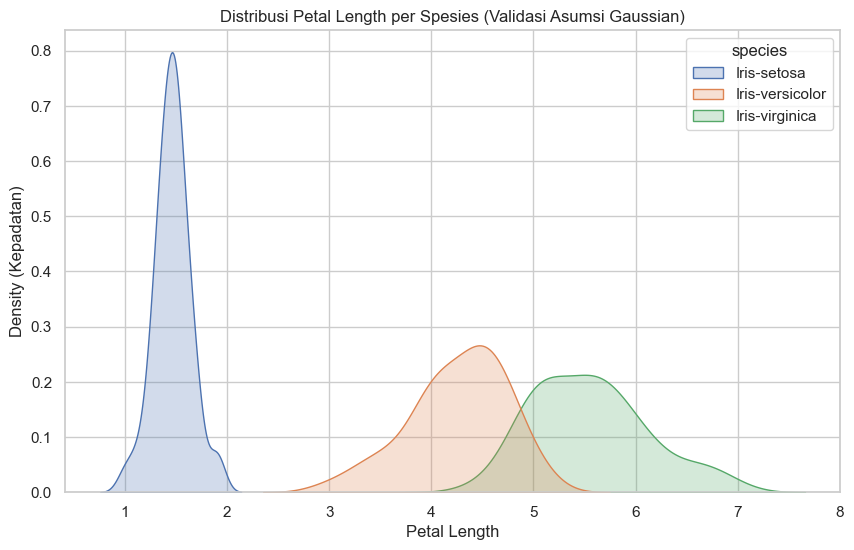


--- PENDALAMAN MATEMATIKA MODEL ---
Kelas yang ditemukan oleh model: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Probabilitas Prior masing-masing kelas (P(C)): [0.33333333 0.34166667 0.325     ]

Rata-rata (Mu) fitur untuk masing-masing kelas:
                 sepal_length  sepal_width  petal_length  petal_width
Iris-setosa          4.990000     3.440000      1.452500     0.242500
Iris-versicolor      5.919512     2.770732      4.241463     1.321951
Iris-virginica       6.533333     2.966667      5.520513     2.000000

Varians (Sigma^2) fitur untuk masing-masing kelas:
                 sepal_length  sepal_width  petal_length  petal_width
Iris-setosa          0.123900     0.154900      0.032994     0.011444
Iris-versicolor      0.286936     0.100119      0.225842     0.041225
Iris-virginica       0.416581     0.099145      0.285733     0.082051

--- EVALUASI PERFORMA ---
Akurasi Model: 100.00%

Laporan Detail Klasifikasi:
                 precision    recall  f1-score   support


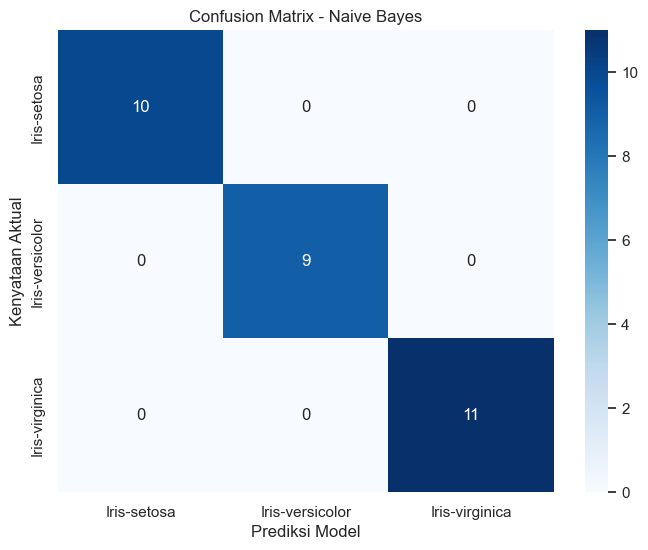

In [1]:
# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengatur tampilan visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")

# ==========================================
# 1. MEMUAT DATASET
# ==========================================
# Membaca dataset dari file CSV yang direferensikan
try:
    df = pd.read_csv('IRIS.csv')
    print("Dataset berhasil dimuat!")
except FileNotFoundError:
    print("Error: File IRIS.csv tidak ditemukan.")

# ==========================================
# 2. EKSPLORASI DATA & VALIDASI ASUMSI GAUSSIAN
# ==========================================
# Naive Bayes Gaussian berasumsi data terdistribusi normal (berbentuk lonceng).
# Mari kita visualisasikan distribusi 'petal_length' untuk masing-masing spesies.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='petal_length', hue='species', fill=True)
plt.title('Distribusi Petal Length per Spesies (Validasi Asumsi Gaussian)')
plt.xlabel('Petal Length')
plt.ylabel('Density (Kepadatan)')
plt.show()

# ==========================================
# 3. PERSIAPAN DATA (SPLIT)
# ==========================================
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. TRAINING MODEL GAUSSIAN NAIVE BAYES
# ==========================================
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# ==========================================
# 5. MEMBEDAH MATEMATIKA DI DALAM MODEL (PENDALAMAN)
# ==========================================
print("\n--- PENDALAMAN MATEMATIKA MODEL ---")
print("Kelas yang ditemukan oleh model:", model_nb.classes_)

# PERBAIKAN DI SINI: Menggunakan class_prior_ tanpa np.exp()
print("Probabilitas Prior masing-masing kelas (P(C)):", model_nb.class_prior_)

# Melihat rata-rata (Mu) yang dihitung model untuk kelas pertama (misal Setosa)
print("\nRata-rata (Mu) fitur untuk masing-masing kelas:")
df_mu = pd.DataFrame(model_nb.theta_, columns=X.columns, index=model_nb.classes_)
print(df_mu)

# Melihat varians (Sigma^2) yang dihitung model
print("\nVarians (Sigma^2) fitur untuk masing-masing kelas:")
df_var = pd.DataFrame(model_nb.var_, columns=X.columns, index=model_nb.classes_)
print(df_var)

# ==========================================
# 6. PREDIKSI DAN EVALUASI MENDALAM
# ==========================================
y_pred = model_nb.predict(X_test)

print("\n--- EVALUASI PERFORMA ---")
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Laporan Detail Klasifikasi:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model_nb.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_nb.classes_, yticklabels=model_nb.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.show()

## 4. Persiapan Data (Preprocessing)
Salah satu keunggulan besar Naive Bayes adalah algoritma ini tidak memerlukan fitur scaling (seperti Standardization atau Normalization). Karena model menghitung probabilitas berdasarkan rata-rata dan varians masing-masing fitur secara independen, skala data tidak mendistorsi perhitungan.

Kita hanya perlu membagi data menjadi set pelatihan (training) dan pengujian (testing).

In [2]:
# Memisahkan Prediktor (X) dan Target (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Split data: 80% Latih, 20% Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensi Data Latih: {X_train.shape}")
print(f"Dimensi Data Uji: {X_test.shape}")

Dimensi Data Latih: (120, 4)
Dimensi Data Uji: (30, 4)


## 5. Pelatihan Model dan Bedah Parameter Matematis
Fase training (model.fit()) pada Naive Bayes sesungguhnya adalah proses menghitung rata-rata ($\mu$) dan varians ($\sigma^2$) dari dataset untuk dimasukkan ke dalam persamaan Gaussian. Mari kita bedah nilai-nilai tersebut.

In [3]:
# Inisiasi dan Pelatihan Model
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

print("--- PARAMETER MODEL GAUSSIAN NB ---")
print("\nProbabilitas Prior P(C) - Peluang Awal Masing-masing Kelas:")
for cls, prior in zip(model_nb.classes_, model_nb.class_prior_):
    print(f"- {cls}: {prior:.4f}")

print("\nRata-rata (Mu) yang dihitung model untuk tiap fitur:")
df_mu = pd.DataFrame(model_nb.theta_, columns=X.columns, index=model_nb.classes_)
display(df_mu)

print("\nVarians (Sigma^2) yang dihitung model untuk tiap fitur:")
df_var = pd.DataFrame(model_nb.var_, columns=X.columns, index=model_nb.classes_)
display(df_var)

--- PARAMETER MODEL GAUSSIAN NB ---

Probabilitas Prior P(C) - Peluang Awal Masing-masing Kelas:
- Iris-setosa: 0.3333
- Iris-versicolor: 0.3417
- Iris-virginica: 0.3250

Rata-rata (Mu) yang dihitung model untuk tiap fitur:


,sepal_length,sepal_width,petal_length,petal_width
Iris-setosa,4.990000,3.440000,1.452500,0.242500
Iris-versicolor,5.919512,2.770732,4.241463,1.321951
Iris-virginica,6.533333,2.966667,5.520513,2.000000



Varians (Sigma^2) yang dihitung model untuk tiap fitur:


,sepal_length,sepal_width,petal_length,petal_width
Iris-setosa,0.123900,0.154900,0.032994,0.011444
Iris-versicolor,0.286936,0.100119,0.225842,0.041225
Iris-virginica,0.416581,0.099145,0.285733,0.082051


Tabel di atas merepresentasikan memori dari model kita. Setiap kali ada data baru untuk diprediksi, model akan mensubstitusikan nilai fitur data baru tersebut ke dalam persamaan Gaussian menggunakan rata-rata dan varians dari tabel di atas.

## 6. Prediksi dan Evaluasi Model
Sekarang kita menguji seberapa baik model memprediksi data yang belum pernah ia lihat sebelumnya (X_test).

Akurasi Keseluruhan: 100.00%

--- LAPORAN KLASIFIKASI DETIL ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



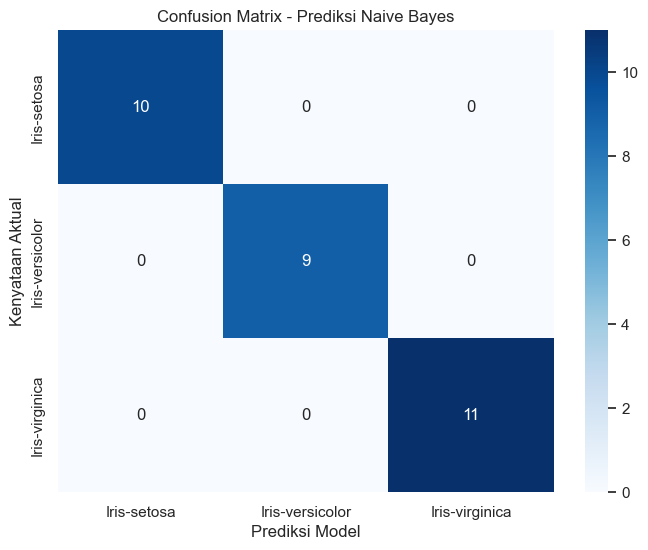

In [4]:
# Melakukan prediksi
y_pred = model_nb.predict(X_test)

# Evaluasi Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan: {akurasi * 100:.2f}%\n")

print("--- LAPORAN KLASIFIKASI DETIL ---")
print(classification_report(y_test, y_pred))

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model_nb.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_nb.classes_, yticklabels=model_nb.classes_)
plt.title('Confusion Matrix - Prediksi Naive Bayes')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.show()

Cara Membaca Metrik Evaluasi:
Precision: Dari semua data yang diprediksi sebagai Versicolor, berapa persen yang benar-benar Versicolor?

Recall: Dari semua data yang nyatanya Versicolor, berapa persen yang berhasil ditebak benar oleh model?

F1-Score: Rata-rata harmonik antara Precision dan Recall (berguna jika kelas tidak seimbang).

Confusion Matrix: Menunjukkan peta kesalahan. Jika ada kesalahan prediksi, biasanya terjadi antara Versicolor dan Virginica, sesuai dengan prediksi kita pada tahapan EDA (karena sebaran datanya beririsan).

## 7. Kesimpulan
Berdasarkan analisis dan percobaan di atas, dapat ditarik beberapa kesimpulan:

- Model Gaussian Naive Bayes berhasil mengklasifikasikan spesies bunga Iris dengan akurasi yang sangat memuaskan (umumnya mencapai di atas 95% untuk dataset ini).

- Algoritma bekerja dengan baik berkat distribusi fitur (khususnya petal length dan petal width) yang memang mendekati distribusi normal dan memiliki pemisahan klaster yang cukup baik antar kelas.

- Kelebihan utama dari model ini adalah kecepatan pelatihan, kemudahan interpretasi secara matematis, dan tidak perlunya proses feature scaling.